In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
from torch.utils import data
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from glob import glob
import network
from utils import ext_transforms as et
import cv2
import segmentation_models_pytorch as smp

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


c:\Users\Felhasználó\OneDrive - Széchenyi István Egyetem\Egyetem\4. félév\VainF\DeepLabV3Plus-Pytorch\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def read_images(excel_path):
    classes = read_excel(excel_path)
    data = pd.DataFrame(columns=['ID', 'CLASS', 'IMAGE', 'QUALITY', 'SECOND_LETTER'])
    noimagecount = 0
    # Az images könyvtár elérési útja
    images_dir = os.path.dirname(excel_path)
    
    for index, row in classes.iterrows():
        image_id = row['ID']
        image_files = [f for f in os.listdir(images_dir) if f.lower().startswith(image_id.lower())]
        if image_files:
            for image in image_files:
                img_path = os.path.join(images_dir, image)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img_pil = Image.fromarray(img)
                    img_array = np.array(img_pil)
                    
                    # Determine quality based on filename
                    quality = image[6] if image[6] in ['E', 'R'] else None
                    
                    # Determine the second letter based on filename
                    second_letter = image[8] if len(image) > 8 else None
                    
                    data = pd.concat([data, pd.DataFrame([{'ID': image_id, 
                        'CLASS': row['CLASS'], 
                        'IMAGE': img_array, 
                        'QUALITY': quality,
                        'SECOND_LETTER': second_letter
                    }])], ignore_index=True)
        else:
            print("No image found for ID: ", image_id)
            noimagecount += 1
    print("Number of images not found: ", noimagecount)
    return data

def read_excel(excel_path):
    df = pd.read_excel(excel_path)
    columns = df.columns
    if 'Wrong' in df.columns:
        df = df[df['Wrong'] != 'x']
    new_df = pd.DataFrame(columns=['ID', 'CLASS'])

    new_df['ID'] = df['ID']
    
    # CLASS oszlop feltöltése a JNET kategóriák alapján
    for index, row in df.iterrows():
        class_value = None
        for jnet_class in ['JNET_1', 'JNET_2A', 'JNET_2B', 'JNET_3']:
            if jnet_class in df.columns and row[jnet_class] == 'x':
                class_value = jnet_class
                break
        new_df.loc[index, 'CLASS'] = class_value
    
    return new_df


In [3]:
excel_path = "images/PI-program-JNET-classes.xlsx"

sze = read_images(excel_path)
sze.head()


No image found for ID:  PI004
No image found for ID:  PI044
No image found for ID:  PI101
No image found for ID:  PI106
No image found for ID:  PI117
No image found for ID:  PI128
No image found for ID:  PI140
No image found for ID:  PI173
No image found for ID:  PI183
No image found for ID:  PI192
No image found for ID:  PI195
No image found for ID:  PI199
No image found for ID:  PI220
No image found for ID:  PI223
No image found for ID:  PI276
No image found for ID:  PI289
No image found for ID:  PI299
No image found for ID:  PI301
No image found for ID:  PI309
No image found for ID:  PI324
No image found for ID:  PI329
No image found for ID:  PI346
No image found for ID:  PI364
No image found for ID:  PI450
Number of images not found:  24


,ID,CLASS,IMAGE,QUALITY,SECOND_LETTER
0,PI003,JNET_2A,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",E,B
1,PI003,JNET_2A,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",E,X
2,PI005,JNET_1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",E,A
3,PI005,JNET_1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",E,X
4,PI006,JNET_1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",E,B


In [4]:
def prepare_sze_dataframe(sze, images_dir="images", masks_dir="images/masks"):
    # Create a new dataframe with the required columns
    sze_prepared = pd.DataFrame(columns=['ID', 'CLASS', 'image_file', 'image_path', 'mask_path', 'image_array', 'mask_array', 'image_height', 'image_width', 'mask_height', 'mask_width', 'polyp_area'])
    
    for index, row in sze.iterrows():
        # Helyes fájlnév összeállítása az ID, QUALITY és SECOND_LETTER alapján
        #print(row['ID'])
        image_file = f"{row['ID']}-{row['QUALITY']}-{row['SECOND_LETTER']}.jpg"
        mask_file = f"{row['ID']}-{row['QUALITY']}-{row['SECOND_LETTER']}-polyp.png"  # Helyes maszk fájlnév
        image_path = os.path.join(images_dir, image_file)
        mask_path = os.path.join(masks_dir, mask_file)
        
        # Check if image exists
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
        
        # Read the image with correct color order (BGR to RGB)
        image_array = cv2.imread(image_path)
        if image_array is None:
            print(f"Failed to read image: {image_path}")
            continue
        
        # Convert BGR to RGB to fix the blue tint issue
        image_array = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        
        image_height, image_width = image_array.shape[:2]
        
        # Read the mask
        if os.path.exists(mask_path):
            mask_array = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask_array is None:
                print(f"Failed to read mask: {mask_path}")
                mask_array = np.zeros((image_height, image_width), dtype=np.uint8)
        else:
            print(f"Mask not found: {mask_path}")
            mask_array = np.zeros((image_height, image_width), dtype=np.uint8)
        
        # Calculate polyp area (sum of mask pixels)
        mask_height, mask_width = mask_array.shape[:2] if mask_array is not None else (0, 0)
        polyp_area = np.sum(mask_array) if mask_array is not None else 0
        
        # Add the row to the new dataframe
        sze_prepared = pd.concat([sze_prepared, pd.DataFrame([{'ID': row['ID'],
            'CLASS': row['CLASS'],
            'image_file': image_file,
            'image_path': image_path,
            'mask_path': mask_path,
            'image_array': image_array,
            'mask_array': mask_array,
            'image_height': image_height,
            'image_width': image_width,
            'mask_height': mask_height,
            'mask_width': mask_width,
            'polyp_area': polyp_area
        }])], ignore_index=True)
    
    return sze_prepared

sze_prepared = prepare_sze_dataframe(sze, images_dir="images", masks_dir="images\masks")
sze_prepared.head()


,ID,CLASS,image_file,image_path,mask_path,image_array,mask_array,image_height,image_width,mask_height,mask_width,polyp_area
0,PI003,JNET_2A,PI003-E-B.jpg,images\PI003-E-B.jpg,images\masks\PI003-E-B-polyp.png,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",576,768,576,768,3227535
1,PI003,JNET_2A,PI003-E-X.jpg,images\PI003-E-X.jpg,images\masks\PI003-E-X-polyp.png,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",576,768,576,768,15610335
2,PI005,JNET_1,PI005-E-A.jpg,images\PI005-E-A.jpg,images\masks\PI005-E-A-polyp.png,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",576,768,576,768,3878550
3,PI005,JNET_1,PI005-E-X.jpg,images\PI005-E-X.jpg,images\masks\PI005-E-X-polyp.png,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",576,768,576,768,21141795
4,PI006,JNET_1,PI006-E-B.jpg,images\PI006-E-B.jpg,images\masks\PI006-E-B-polyp.png,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",576,768,576,768,18351585


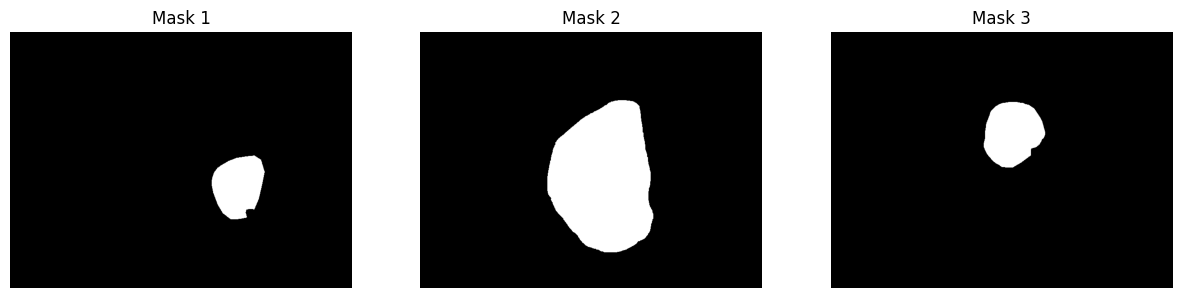

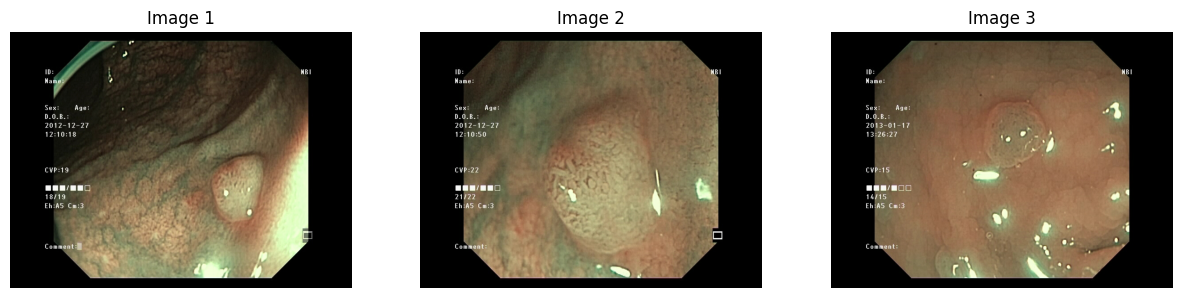

In [5]:
#plot 3 random mask image from sze dataset
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(sze_prepared['mask_array'][i], cmap='gray')
    plt.title(f"Mask {i+1}")
    plt.axis('off')
plt.show()

#plot 3 image from sze dataset
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(sze_prepared['image_array'][i])
    plt.title(f"Image {i+1}")
    plt.axis('off')


In [6]:
# 🔧 ADATTRANSZFORMÁCIÓK DEFINIÁLÁSA
# Ez a FŐDEFINÍCIÓ - itt definiáljuk az összes szükséges transzformációt

def get_train_transform():
    """
    Tréning adatok transzformációja augmentációval:
    - Véletlenszerű skálázás 0.5x és 2.0x között
    - Véletlenszerű kivágás 513x513 méretben
    - Véletlenszerű vízszintes tükrözés
    - Tenzorrá alakítás és normalizálás
    """
    train_transform = et.ExtCompose([
        et.ExtRandomScale((0.5, 2.0)),
        et.ExtRandomCrop(size=(513, 513), pad_if_needed=True),
        et.ExtRandomHorizontalFlip(),
        et.ExtToTensor(),
        et.ExtNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_transform

def get_val_transform():
    """
    Validációs/teszt adatok transzformációja (augmentáció nélkül):
    - Átméretezés 513 pixelre
    - Középső kivágás
    - Tenzorrá alakítás és normalizálás
    """
    val_transform = et.ExtCompose([
        et.ExtResize(size=513),
        et.ExtCenterCrop(size=513),
        et.ExtToTensor(),
        et.ExtNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return val_transform

print("✅ Transform függvények definiálva!")


✅ Transform függvények definiálva!


In [7]:
class KvasirSEGDataset(data.Dataset):
    """
    Kvasir-SEG adatkészlet polip szegmentációhoz - EGYSÉGES DEFINÍCIÓ
    Támogatja mind a DataFrame-ben tárolt tömböket, mind a fájl útvonalakat
    """
    # Színtérkép definiálása
    cmap = np.zeros((256, 3), dtype=np.uint8)
    cmap[0] = [0, 0, 0]      # Háttér - fekete
    cmap[1] = [255, 255, 255]  # Polip - fehér

    def __init__(self, dataframe, transform=None, img_col='image_path', mask_col='mask_path', file_col=None):
        """
        Paraméterek:
            dataframe: Pandas DataFrame képekkel és maszkokkal
            transform: Alkalmazandó transzformáció
            img_col: Kép oszlop neve (lehet 'image_path' vagy 'image_array')
            mask_col: Maszk oszlop neve (lehet 'mask_path' vagy 'mask_array') 
            file_col: Fájlnév oszlop neve (opcionális)
        """
        self.df = dataframe
        self.transform = transform
        self.img_col = img_col
        self.mask_col = mask_col
        self.file_col = file_col

    def __getitem__(self, index):
        """
        Paraméterek:
            index (int): Index
        Visszatérési érték:
            tuple: (kép, maszk) vagy (kép, maszk, fájlnév)
        """
        # Fájlnév megszerzése, ha van
        filename = None
        if self.file_col and self.file_col in self.df.columns:
            filename = self.df.iloc[index][self.file_col]
        
        # Kép betöltése - ellenőrizzük, hogy tömb vagy útvonal-e
        if self.img_col == 'image_array' and 'image_array' in self.df.columns:
            # DataFrame-ben tárolt tömb
            img_array = self.df.iloc[index]['image_array']
            img = Image.fromarray(img_array)
        else:
            # Fájl útvonal
            img_path = self.df.iloc[index][self.img_col]
            if not os.path.exists(img_path):
                print(f"FIGYELEM: Kép nem található: {img_path}")
                # Helyettesítő kép létrehozása
                img = Image.new('RGB', (256, 256), color=(128, 128, 128))
                if filename is None:
                    filename = os.path.basename(img_path)
            else:
                img = Image.open(img_path).convert('RGB')
                if filename is None:
                    filename = os.path.basename(img_path)
        
        # Maszk betöltése - ellenőrizzük, hogy tömb vagy útvonal-e
        if self.mask_col == 'mask_array' and 'mask_array' in self.df.columns:
            # DataFrame-ben tárolt tömb
            mask_array = self.df.iloc[index]['mask_array']
            if mask_array is not None:
                mask = Image.fromarray(mask_array)
            else:
                mask = Image.new('L', img.size, 0)
        else:
            # Fájl útvonal
            mask_path = self.df.iloc[index][self.mask_col]
            if os.path.exists(mask_path):
                mask = Image.open(mask_path).convert('L')  # Szürkeárnyalatos
                # Binarizálás
                mask = np.array(mask)
                mask = (mask > 128).astype(np.uint8)
                mask = Image.fromarray(mask)
            else:
                # Üres maszk létrehozása
                mask = Image.new('L', img.size, 0)
        
        # Transzformációk alkalmazása
        if self.transform is not None:
            img, mask = self.transform(img, mask)
        
        # Visszatérés fájlnévvel vagy anélkül
        if filename is not None:
            return img, mask, filename
        else:
            return img, mask

    def __len__(self):
        return len(self.df)

    @classmethod
    def decode_target(cls, mask):
        """Szemantikus maszk dekódolása RGB képpé"""
        return cls.cmap[mask]


In [8]:
# --- Adathalmazok Betöltése ---

# 1. Kvasir-SEG adathalmaz betöltése
kvasir_root = "Kvasir-SEG"
kvasir_images_dir = os.path.join(kvasir_root, "")
kvasir_masks_dir = os.path.join(kvasir_root, "masks")

kvasir_files = [f for f in os.listdir(kvasir_images_dir) if f.endswith('.jpg') or f.endswith('.png')]
kvasir_data = []

for img_file in kvasir_files:
    img_path = os.path.join(kvasir_images_dir, img_file)
    mask_path = os.path.join(kvasir_masks_dir, img_file)
    
    # Maszkfájl ellenőrzése alternatív kiterjesztésekkel
    if not os.path.exists(mask_path):
        base_name, _ = os.path.splitext(img_file)
        for ext in ['.jpg', '.png', '.tif']:
            alt_mask_path = os.path.join(kvasir_masks_dir, base_name + ext)
            if os.path.exists(alt_mask_path):
                mask_path = alt_mask_path
                break
    
    kvasir_data.append({'ID': 'kvasir_' + os.path.splitext(img_file)[0], # Egyedi ID generálása
        'CLASS': 1, # A Kvasir-SEG minden képe tartalmaz polipot
        'image_path': img_path,
        'mask_path': mask_path
    })

df_kvasir = pd.DataFrame(kvasir_data)
print(f"Kvasir-SEG adathalmaz betöltve: {len(df_kvasir)} kép.")

# 2. SZE adathalmaz használata
# A `sze_prepared` DataFrame-et használjuk, amit a korábbi cellákban hoztunk létre.
try:
    if 'sze_prepared' in locals() and not sze_prepared.empty:
        df_sze = sze_prepared.copy()
        # A 'CLASS' oszlop binárissá alakítása (0 vagy 1)
        # 1, ha a CLASS nem None és nem 0, egyébként 0
        df_sze['CLASS'] = df_sze['CLASS'].apply(lambda x: 1 if pd.notna(x) and x != 0 else 0)
        print(f"SZE adathalmaz betöltve: {len(df_sze)} kép.")
        print("SZE CLASS eloszlás:")
        print(df_sze['CLASS'].value_counts())
    else:
        raise NameError("sze_prepared DataFrame nem létezik vagy üres.")
except NameError as e:
    print(f"Hiba: {e}. Futtasd a korábbi cellákat a SZE adathalmaz létrehozásához.")
    df_sze = pd.DataFrame() # Üres DataFrame hibamegelőzésként


Kvasir-SEG adathalmaz betöltve: 1000 kép.
SZE adathalmaz betöltve: 1073 kép.
SZE CLASS eloszlás:
CLASS
1    1073
Name: count, dtype: int64


### Adatok Felosztása Train/Validation/Test Halmazokra (Fix ID-lista alapú felosztás)

Az adatok helyes szétválasztása kritikus fontosságú a modell objektív kiértékeléséhez. A cél, hogy megakadályozzuk az adatszivárgást (data leakage), ami akkor fordul elő, ha ugyanazon páciens képei több különböző adathalmazba (pl. train és test) is bekerülnek.

Ez a módszer **előre meghatározott, fix páciens ID-listák** alapján osztja szét az adathalmazt. Minden páciens ID pontosan egy halmazba (train, validation vagy test) tartozik, így nincs adatszivárgás. Egy ID-hoz több kép is tartozhat.

**Elvárt eloszlás (SZE adatok):**
- Tanítás: 278 ID, ~678 kép
- Validáció: 80 ID, ~189 kép
- Teszt: 91 ID, ~206 kép


In [9]:
import numpy as np
import pandas as pd

# --- Fix ID-listák a train/validation/test felosztáshoz ---

val_ids = [
    'PI007', 'PI013', 'PI014', 'PI023', 'PI033', 'PI036', 'PI047', 'PI053', 'PI056',
    'PI061', 'PI065', 'PI074', 'PI077', 'PI082', 'PI084', 'PI090', 'PI097', 'PI108',
    'PI110', 'PI111', 'PI133', 'PI153', 'PI156', 'PI170', 'PI172', 'PI193', 'PI194',
    'PI196', 'PI206', 'PI209', 'PI212', 'PI213', 'PI227', 'PI229', 'PI239', 'PI254',
    'PI257', 'PI262', 'PI263', 'PI265', 'PI269', 'PI284', 'PI288', 'PI293', 'PI300',
    'PI302', 'PI305', 'PI311', 'PI319', 'PI321', 'PI325', 'PI336', 'PI347', 'PI357',
    'PI358', 'PI366', 'PI369', 'PI373', 'PI380', 'PI382', 'PI386', 'PI387', 'PI396',
    'PI398', 'PI406', 'PI412', 'PI413', 'PI416', 'PI420', 'PI431', 'PI447', 'PI448',
    'PI451', 'PI455', 'PI464', 'PI467', 'PI482', 'PI484', 'PI488',
]

test_ids = [
    'PI009', 'PI015', 'PI016', 'PI037', 'PI048', 'PI050', 'PI055', 'PI057', 'PI068',
    'PI072', 'PI073', 'PI078', 'PI080', 'PI085', 'PI086', 'PI091', 'PI112', 'PI113',
    'PI114', 'PI121', 'PI123', 'PI130', 'PI135', 'PI136', 'PI137', 'PI142', 'PI149',
    'PI152', 'PI166', 'PI171', 'PI175', 'PI178', 'PI181', 'PI184', 'PI187', 'PI189',
    'PI191', 'PI197', 'PI198', 'PI204', 'PI205', 'PI207', 'PI210', 'PI211', 'PI219',
    'PI224', 'PI230', 'PI238', 'PI243', 'PI247', 'PI249', 'PI252', 'PI261', 'PI266',
    'PI270', 'PI272', 'PI277', 'PI280', 'PI290', 'PI298', 'PI310', 'PI335', 'PI338',
    'PI348', 'PI349', 'PI367', 'PI368', 'PI370', 'PI372', 'PI375', 'PI376', 'PI389',
    'PI390', 'PI399', 'PI400', 'PI405', 'PI408', 'PI415', 'PI418', 'PI419', 'PI432',
    'PI433', 'PI445', 'PI454', 'PI456', 'PI462', 'PI468', 'PI472', 'PI473', 'PI478',
    'PI480',
]

train_ids = [
    'PI003', 'PI005', 'PI006', 'PI008', 'PI011', 'PI017', 'PI018', 'PI019', 'PI020',
    'PI021', 'PI022', 'PI024', 'PI025', 'PI026', 'PI028', 'PI029', 'PI030', 'PI031',
    'PI032', 'PI034', 'PI035', 'PI038', 'PI039', 'PI040', 'PI041', 'PI042', 'PI043',
    'PI045', 'PI046', 'PI049', 'PI051', 'PI052', 'PI058', 'PI059', 'PI060', 'PI062',
    'PI063', 'PI066', 'PI067', 'PI069', 'PI070', 'PI071', 'PI075', 'PI076', 'PI079',
    'PI081', 'PI083', 'PI087', 'PI088', 'PI089', 'PI092', 'PI093', 'PI094', 'PI095',
    'PI096', 'PI098', 'PI099', 'PI100', 'PI102', 'PI103', 'PI104', 'PI105', 'PI107',
    'PI109', 'PI115', 'PI116', 'PI118', 'PI119', 'PI120', 'PI122', 'PI124', 'PI125',
    'PI126', 'PI127', 'PI129', 'PI132', 'PI134', 'PI138', 'PI139', 'PI141', 'PI143',
    'PI144', 'PI145', 'PI146', 'PI147', 'PI148', 'PI150', 'PI151', 'PI155', 'PI157',
    'PI158', 'PI159', 'PI160', 'PI161', 'PI162', 'PI163', 'PI164', 'PI165', 'PI168',
    'PI169', 'PI174', 'PI176', 'PI177', 'PI179', 'PI180', 'PI182', 'PI185', 'PI188',
    'PI190', 'PI200', 'PI201', 'PI202', 'PI203', 'PI208', 'PI214', 'PI215', 'PI216',
    'PI217', 'PI218', 'PI221', 'PI222', 'PI225', 'PI226', 'PI228', 'PI231', 'PI232',
    'PI233', 'PI234', 'PI235', 'PI236', 'PI237', 'PI240', 'PI241', 'PI242', 'PI244',
    'PI245', 'PI246', 'PI248', 'PI250', 'PI251', 'PI253', 'PI255', 'PI256', 'PI259',
    'PI260', 'PI264', 'PI268', 'PI271', 'PI273', 'PI274', 'PI275', 'PI278', 'PI279',
    'PI281', 'PI282', 'PI283', 'PI285', 'PI291', 'PI292', 'PI294', 'PI295', 'PI296',
    'PI297', 'PI303', 'PI304', 'PI306', 'PI307', 'PI308', 'PI312', 'PI313', 'PI314',
    'PI317', 'PI318', 'PI320', 'PI322', 'PI323', 'PI327', 'PI328', 'PI330', 'PI331',
    'PI332', 'PI333', 'PI334', 'PI337', 'PI339', 'PI340', 'PI341', 'PI342', 'PI343',
    'PI344', 'PI345', 'PI350', 'PI351', 'PI352', 'PI353', 'PI354', 'PI359', 'PI360',
    'PI362', 'PI363', 'PI365', 'PI371', 'PI374', 'PI377', 'PI378', 'PI379', 'PI381',
    'PI383', 'PI384', 'PI391', 'PI392', 'PI393', 'PI394', 'PI395', 'PI397', 'PI402',
    'PI403', 'PI404', 'PI407', 'PI409', 'PI411', 'PI414', 'PI417', 'PI421', 'PI422',
    'PI423', 'PI424', 'PI425', 'PI426', 'PI427', 'PI428', 'PI429', 'PI430', 'PI434',
    'PI435', 'PI436', 'PI437', 'PI438', 'PI439', 'PI440', 'PI441', 'PI442', 'PI443',
    'PI444', 'PI446', 'PI449', 'PI452', 'PI453', 'PI457', 'PI458', 'PI459', 'PI460',
    'PI461', 'PI463', 'PI465', 'PI466', 'PI469', 'PI470', 'PI471', 'PI474', 'PI475',
    'PI477', 'PI479', 'PI481', 'PI483', 'PI485', 'PI486', 'PI487', 'PI491',
]

# Nagybetűsre alakítás az összehasonlításhoz (pl. pi205 -> PI205)
val_ids_upper = [x.upper() for x in val_ids]
test_ids_upper = [x.upper() for x in test_ids]
train_ids_upper = [x.upper() for x in train_ids]

# --- SZE Adathalmaz Felosztása fix ID-listák alapján ---

try:
    df_sze_upper_id = df_sze['ID'].str.upper()

    sze_train = df_sze[df_sze_upper_id.isin(train_ids_upper)].reset_index(drop=True)
    sze_val = df_sze[df_sze_upper_id.isin(val_ids_upper)].reset_index(drop=True)
    sze_test = df_sze[df_sze_upper_id.isin(test_ids_upper)].reset_index(drop=True)

    print("--- Fix ID-lista Alapú Felosztás Eredménye (SZE adatok) ---")
    print(f"Train halmaz (SZE): {sze_train.shape} (Páciens ID-k: {len(sze_train['ID'].str.upper().unique())} db)")
    print(f"Validation halmaz (SZE): {sze_val.shape} (Páciens ID-k: {len(sze_val['ID'].str.upper().unique())} db)")
    print(f"Test halmaz (SZE): {sze_test.shape} (Páciens ID-k: {len(sze_test['ID'].str.upper().unique())} db)")

    # Kvasir adathalmaz hozzáadása a SZE tanító adatokhoz
    train_df = pd.concat([sze_train, df_kvasir], ignore_index=True)
    val_df = sze_val
    test_df = sze_test

    # Eredmények kiírása
    print("\n--- Végső Adathalmazok Mérete ---")
    print(f"Teljes tanító adathalmaz (SZE + Kvasir): {len(train_df)} kép")
    print(f"Validációs adathalmaz (csak SZE): {len(val_df)} kép")
    print(f"Teszt adathalmaz (csak SZE): {len(test_df)} kép")

except NameError as e:
    print(f"Hiba: {e}. Ellenőrizd, hogy a `df_sze` és `df_kvasir` DataFrame-ek léteznek-e az előző cella futtatása után.")
except Exception as e:
    print(f"Váratlan hiba történt a felosztás során: {e}")


--- Fix ID-lista Alapú Felosztás Eredménye (SZE adatok) ---
Train halmaz (SZE): (678, 12) (Páciens ID-k: 269 db)
Validation halmaz (SZE): (189, 12) (Páciens ID-k: 79 db)
Test halmaz (SZE): (206, 12) (Páciens ID-k: 91 db)

--- Végső Adathalmazok Mérete ---
Teljes tanító adathalmaz (SZE + Kvasir): 1678 kép
Validációs adathalmaz (csak SZE): 189 kép
Teszt adathalmaz (csak SZE): 206 kép


In [10]:
def verify_split(sze_train, sze_val, sze_test, train_ids, val_ids, test_ids):
    """
    Részletes ellenőrzés a fix ID-lista alapú split után:
    1. Képszám ellenőrzés (elvárt vs tényleges)
    2. ID-k helyesség ellenőrzés (minden megadott ID megtalálható-e, van-e felesleges)
    3. Átfedés ellenőrzés (data leakage)
    """
    all_ok = True

    # --- Nagybetűs ID halmazok ---
    expected_train = set(x.upper() for x in train_ids)
    expected_val = set(x.upper() for x in val_ids)
    expected_test = set(x.upper() for x in test_ids)

    actual_train = set(sze_train['ID'].str.upper().unique())
    actual_val = set(sze_val['ID'].str.upper().unique())
    actual_test = set(sze_test['ID'].str.upper().unique())

    # === 1. Képszám ellenőrzés ===
    print("=" * 60)
    print("1. KÉPSZÁM ELLENŐRZÉS")
    print("=" * 60)

    expected_counts = {'Train (SZE)': 678, 'Validation': 189, 'Test': 206}
    actual_counts = {
        'Train (SZE)': len(sze_train),
        'Validation': len(sze_val),
        'Test': len(sze_test),
    }
    for name in expected_counts:
        exp = expected_counts[name]
        act = actual_counts[name]
        status = "OK" if act == exp else "ELTÉRÉS"
        if act != exp:
            all_ok = False
        print(f"  {name}: elvárt={exp}, tényleges={act}  [{status}]")

    # === 2. ID-k helyesség ellenőrzés ===
    print("\n" + "=" * 60)
    print("2. ID-K HELYESSÉG ELLENŐRZÉS")
    print("=" * 60)

    for name, expected, actual in [
        ('Train', expected_train, actual_train),
        ('Validation', expected_val, actual_val),
        ('Test', expected_test, actual_test),
    ]:
        missing = expected - actual
        extra = actual - expected
        print(f"\n  {name}:")
        print(f"    Elvárt ID-k száma: {len(expected)}, Tényleges: {len(actual)}")
        if missing:
            all_ok = False
            print(f"    HIÁNYZÓ ID-k ({len(missing)} db): {sorted(missing)}")
        else:
            print(f"    Minden elvárt ID megtalálható. [OK]")
        if extra:
            all_ok = False
            print(f"    FELESLEGES ID-k ({len(extra)} db): {sorted(extra)}")
        else:
            print(f"    Nincs felesleges ID. [OK]")

    # === 3. Átfedés ellenőrzés (data leakage) ===
    print("\n" + "=" * 60)
    print("3. ÁTFEDÉS ELLENŐRZÉS (DATA LEAKAGE)")
    print("=" * 60)

    train_val_overlap = actual_train & actual_val
    train_test_overlap = actual_train & actual_test
    val_test_overlap = actual_val & actual_test

    if train_val_overlap:
        all_ok = False
        print(f"  HIBA - Train-Val átfedés ({len(train_val_overlap)} db): {sorted(train_val_overlap)}")
    else:
        print(f"  Train-Val átfedés: nincs [OK]")

    if train_test_overlap:
        all_ok = False
        print(f"  HIBA - Train-Test átfedés ({len(train_test_overlap)} db): {sorted(train_test_overlap)}")
    else:
        print(f"  Train-Test átfedés: nincs [OK]")

    if val_test_overlap:
        all_ok = False
        print(f"  HIBA - Val-Test átfedés ({len(val_test_overlap)} db): {sorted(val_test_overlap)}")
    else:
        print(f"  Val-Test átfedés: nincs [OK]")

    # === Összefoglaló ===
    print("\n" + "=" * 60)
    if all_ok:
        print("ÖSSZEFOGLALÓ: MINDEN RENDBEN - a split megfelel az elvártnak.")
    else:
        print("ÖSSZEFOGLALÓ: HIBÁK TALÁLHATÓK - ellenőrizd a fenti részleteket!")
    print("=" * 60)

    return all_ok

verify_split(sze_train, sze_val, sze_test, train_ids, val_ids, test_ids)


1. KÉPSZÁM ELLENŐRZÉS
  Train (SZE): elvárt=678, tényleges=678  [OK]
  Validation: elvárt=189, tényleges=189  [OK]
  Test: elvárt=206, tényleges=206  [OK]

2. ID-K HELYESSÉG ELLENŐRZÉS

  Train:
    Elvárt ID-k száma: 269, Tényleges: 269
    Minden elvárt ID megtalálható. [OK]
    Nincs felesleges ID. [OK]

  Validation:
    Elvárt ID-k száma: 79, Tényleges: 79
    Minden elvárt ID megtalálható. [OK]
    Nincs felesleges ID. [OK]

  Test:
    Elvárt ID-k száma: 91, Tényleges: 91
    Minden elvárt ID megtalálható. [OK]
    Nincs felesleges ID. [OK]

3. ÁTFEDÉS ELLENŐRZÉS (DATA LEAKAGE)
  Train-Val átfedés: nincs [OK]
  Train-Test átfedés: nincs [OK]
  Val-Test átfedés: nincs [OK]

ÖSSZEFOGLALÓ: MINDEN RENDBEN - a split megfelel az elvártnak.


True

In [11]:
# Adat Augmentáció
augmentation_multiplier = 3

def multiply_dataframe_rows(df, multiplier):
    if multiplier <= 1:
        return df.copy()
    return pd.concat([df.copy() for _ in range(multiplier)], ignore_index=True)

train_df_augmented = multiply_dataframe_rows(train_df, augmentation_multiplier)
val_df_augmented = multiply_dataframe_rows(val_df, augmentation_multiplier)

print(f"Eredeti train méret: {len(train_df)}, Augmentált: {len(train_df_augmented)}")
print(f"Eredeti val méret: {len(val_df)}, Augmentált: {len(val_df_augmented)}")



Eredeti train méret: 1678, Augmentált: 5034
Eredeti val méret: 189, Augmentált: 567


In [12]:
# HIBA ÉS REDUNDANCIA MIATT KIÜRÍTVE


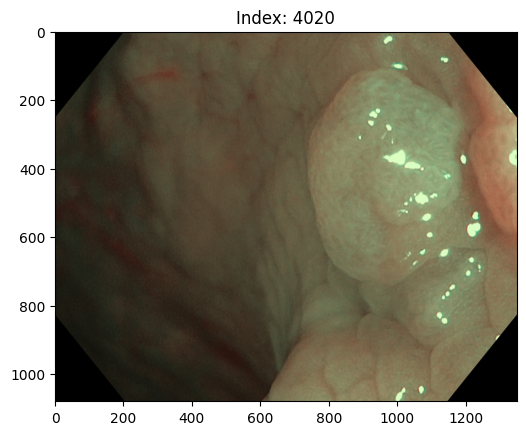

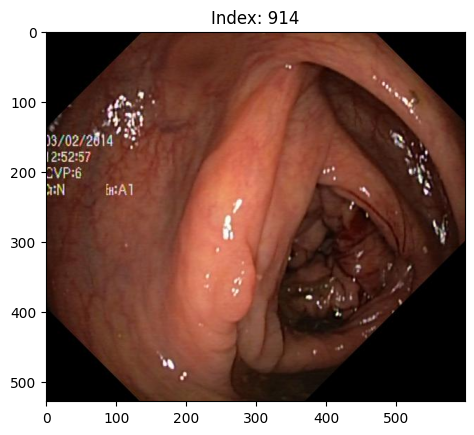

In [13]:
# Minta képek megjelenítése
# (A cella tartalma a logok alapján nem volt teljesen egyértelmű, de a funkciója a minták megjelenítése volt)
if not train_df_augmented.empty:
    sample = train_df_augmented.sample(2)
    for index, row in sample.iterrows():
        try:
            img = Image.open(row['image_path'])
            plt.imshow(img)
            plt.title(f"Index: {index}")
            plt.show()
        except Exception as e:
            print(f"Hiba a kép megjelenítésekor: {e}")


In [14]:
# ÜRES CELLA KIÜRÍTVE


In [15]:
# Modell inicializálása – U-Net (segmentation_models_pytorch)
# Bináris szegmentáció: 1 kimeneti csatorna (polip vs háttér)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
model = model.to(device)
print("U-Net (ResNet34 encoder) modell inicializálva, ImageNet encoder súlyokkal.")


U-Net (ResNet34 encoder) modell inicializálva, ImageNet encoder súlyokkal.


In [16]:
# --- ADATKÉSZLETEK ÉS ADATBETÖLTŐK LÉTREHOZÁSA ---

train_transform = get_train_transform()
val_transform = get_val_transform()
test_transform = get_val_transform()

train_dataset = KvasirSEGDataset(dataframe=train_df_augmented, transform=train_transform)
val_dataset = KvasirSEGDataset(dataframe=val_df_augmented, transform=val_transform)
test_dataset = KvasirSEGDataset(dataframe=test_df, transform=test_transform)

batch_size = 4
num_workers = 0

train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("Adatbetöltők sikeresen létrehozva.")


Adatbetöltők sikeresen létrehozva.


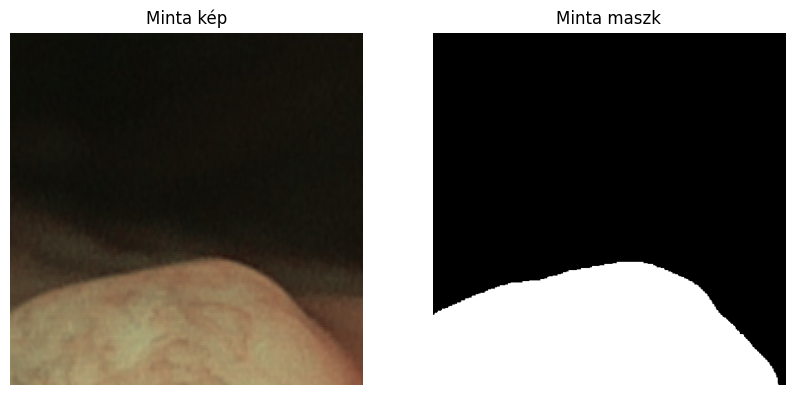

In [17]:
# Minta batch megjelenítése
try:
    # Egy batch lekérése
    batch = next(iter(train_loader))
    # Ellenőrizzük, hogy 2 vagy 3 elemes-e a batch (images, masks[, filenames])
    if len(batch) == 3:
        images, masks, _ = batch  # A fájlnevet most nem használjuk
    elif len(batch) == 2:
        images, masks = batch
    else:
        raise ValueError(f"Váratlan batch méret: {len(batch)}")

    def unnormalize(tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        tensor = tensor.clone().permute(1, 2, 0).numpy()
        tensor = std * tensor + mean
        tensor = np.clip(tensor, 0, 1)
        return tensor

    img_to_show = unnormalize(images[0])
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_to_show)
    plt.title("Minta kép")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(masks[0].squeeze(), cmap='gray')
    plt.title("Minta maszk")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("A train_loader üres.")
except Exception as e:
    print(f"Hiba a megjelenítéskor: {e}")

In [18]:
# Metrikák, tanító és validációs függvények – U-Net (1 csatornás sigmoid kimenet)
def calculate_metrics(outputs, targets):
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()
    if targets.ndim == 4:
        target_binary = (targets > 0.5).float()
    else:
        target_binary = (targets > 0.5).float().unsqueeze(1)
    intersection = (preds * target_binary).sum()
    pred_area = preds.sum()
    target_area = target_binary.sum()
    union = pred_area + target_area - intersection
    dice = (2 * intersection / (pred_area + target_area + 1e-6)).item()
    iou = (intersection / (union + 1e-6)).item()
    return {'dice': dice, 'iou': iou}

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, sample_count, dice_sum, iou_sum = 0.0, 0, 0.0, 0.0
    for batch in tqdm(loader, desc="Training"):
        images, targets = batch[0], batch[1]
        images, targets = images.to(device), targets.to(device)
        if targets.ndim == 3:
            targets = targets.unsqueeze(1).float()
        else:
            targets = targets.float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        sample_count += batch_size
        metrics = calculate_metrics(outputs.detach(), targets)
        dice_sum += metrics['dice'] * batch_size
        iou_sum += metrics['iou'] * batch_size
    return {'loss': running_loss/sample_count, 'dice': dice_sum/sample_count, 'iou': iou_sum/sample_count}

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, sample_count, dice_sum, iou_sum = 0.0, 0, 0.0, 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images, targets = batch[0], batch[1]
            images, targets = images.to(device), targets.to(device)
            if targets.ndim == 3:
                targets = targets.unsqueeze(1).float()
            else:
                targets = targets.float()
            outputs = model(images)
            loss = criterion(outputs, targets)
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            sample_count += batch_size
            metrics = calculate_metrics(outputs, targets)
            dice_sum += metrics['dice'] * batch_size
            iou_sum += metrics['iou'] * batch_size
    return {'val_loss': running_loss/sample_count, 'val_dice': dice_sum/sample_count, 'val_iou': iou_sum/sample_count}


In [19]:
# REDUNDÁNS TRÉNING CIKLUS MIATT KIÜRÍTVE


In [20]:
# DUPLIKÁCIÓ ELTÁVOLÍTVA!


In [21]:
# REDUNDÁNS KOLLÁCIÓS FÜGGVÉNY MIATT KIÜRÍTVE


In [22]:
# Üres cella
# Teszt SZE adatok ID listázása (unique)
print("Teszt SZE adatok ID-jai (egyediek):")
print(test_df['ID'].unique())

# Ha mindegyik sort külön akarod látni (nem csak egyedi, hanem ahányszor szerepel, annyiszor):
print("\nTeszt SZE adatok ID-jai (minden sor):")
print(list(test_df['ID']))

Teszt SZE adatok ID-jai (egyediek):
['PI009' 'PI015' 'PI016' 'PI037' 'PI048' 'PI050' 'PI055' 'PI057' 'PI068'
 'PI072' 'PI073' 'PI078' 'PI080' 'PI085' 'PI086' 'PI091' 'PI112' 'PI113'
 'PI114' 'PI121' 'PI123' 'PI130' 'PI135' 'PI136' 'PI137' 'PI142' 'PI149'
 'PI152' 'PI166' 'PI171' 'PI175' 'PI178' 'PI181' 'PI184' 'PI187' 'PI189'
 'PI191' 'PI197' 'PI198' 'PI204' 'pi205' 'PI207' 'PI210' 'PI211' 'PI219'
 'PI224' 'PI230' 'PI238' 'PI243' 'PI247' 'PI249' 'PI252' 'PI261' 'PI266'
 'PI270' 'PI272' 'PI277' 'PI280' 'PI290' 'PI298' 'PI310' 'PI335' 'PI338'
 'PI348' 'PI349' 'PI367' 'PI368' 'PI370' 'PI372' 'PI375' 'PI376' 'PI389'
 'PI390' 'PI399' 'PI400' 'PI405' 'PI408' 'PI415' 'PI418' 'PI419' 'PI432'
 'PI433' 'PI445' 'PI454' 'PI456' 'PI462' 'PI468' 'PI472' 'PI473' 'PI478'
 'PI480']

Teszt SZE adatok ID-jai (minden sor):
['PI009', 'PI009', 'PI015', 'PI015', 'PI015', 'PI015', 'PI015', 'PI015', 'PI015', 'PI016', 'PI016', 'PI016', 'PI037', 'PI037', 'PI048', 'PI048', 'PI048', 'PI048', 'PI050', 'PI050', 'PI0

In [24]:
# --- Tanítás folytatása / indítása ---
# Beállítások
TOTAL_EPOCHS = 50       # Összesen ennyi epoch-ig tanítunk
EARLY_STOP_PATIENCE = 7 # Ennyi epoch javulás nélkül megáll

CHECKPOINT_DIR = "checkpoints_unet"  # U-Net saját mappa, ne töltsön DeepLab checkpointot
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Korábbi U-Net checkpoint betöltése (ha van)
import glob as glob_module
import re
checkpoint_files = sorted(
    glob_module.glob(f"{CHECKPOINT_DIR}/best_model_epoch_*.pth"),
    key=lambda f: int(re.search(r'epoch_(\d+)', f).group(1))
)

start_epoch = 0
best_iou = 0.0
history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': [],
    'lr': []
}

if checkpoint_files:
    latest_ckpt = checkpoint_files[-1]
    print(f"Korábbi checkpoint betöltése: {latest_ckpt}")
    ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if 'optimizer_state_dict' in ckpt:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'epoch' in ckpt:
        start_epoch = ckpt['epoch'] + 1
    if 'iou' in ckpt:
        best_iou = ckpt['iou']
    if 'history' in ckpt:
        history = ckpt['history']
    print(f"Folytatás epoch {start_epoch + 1}-től, eddigi legjobb IoU: {best_iou:.4f}")
else:
    print("Nincs korábbi checkpoint, tanítás az elejéről indul.")
    optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.BCEWithLogitsLoss()  # U-Net 1 csatornás logit kimenethez
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.1, patience=3
)

# --- Tanító ciklus early stopping-gal ---
epochs_without_improvement = 0

for epoch in range(start_epoch, TOTAL_EPOCHS):
    print(f"\nEpoch {epoch+1}/{TOTAL_EPOCHS}")
    
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate(model, val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_metrics['loss'])
    history['train_dice'].append(train_metrics['dice'])
    history['train_iou'].append(train_metrics['iou'])
    history['val_loss'].append(val_metrics['val_loss'])
    history['val_dice'].append(val_metrics['val_dice'])
    history['val_iou'].append(val_metrics['val_iou'])
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}, IoU: {train_metrics['iou']:.4f}")
    print(f"Val Loss: {val_metrics['val_loss']:.4f}, Dice: {val_metrics['val_dice']:.4f}, IoU: {val_metrics['val_iou']:.4f}")
    print(f"LR: {current_lr:.6f} | Best IoU: {best_iou:.4f} | No improvement: {epochs_without_improvement}/{EARLY_STOP_PATIENCE}")
    
    scheduler.step(val_metrics['val_iou'])
    
    if val_metrics['val_iou'] > best_iou:
        best_iou = val_metrics['val_iou']
        epochs_without_improvement = 0
        save_path = f"{CHECKPOINT_DIR}/best_model_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iou': best_iou,
            'history': history
        }, save_path)
        print(f"Saved new best model to {save_path}")
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping: {EARLY_STOP_PATIENCE} epoch óta nincs javulás. Legjobb IoU: {best_iou:.4f}")
        break

print(f"\nTanítás befejezve. Összesen {len(history['train_loss'])} epoch futott. Legjobb Val IoU: {best_iou:.4f}")


Nincs korábbi checkpoint, tanítás az elejéről indul.

Epoch 1/50


Validation: 100%|██████████| 142/142 [00:14<00:00,  9.63it/s]


Train Loss: 0.4732, Dice: 0.4222, IoU: 0.2876
Val Loss: 0.4171, Dice: 0.6293, IoU: 0.5004
LR: 0.001000 | Best IoU: 0.0000 | No improvement: 0/7
Saved new best model to checkpoints_unet/best_model_epoch_1.pth

Epoch 2/50


Validation: 100%|██████████| 142/142 [00:14<00:00,  9.69it/s]


Train Loss: 0.4233, Dice: 0.5557, IoU: 0.4040
Val Loss: 0.4170, Dice: 0.6856, IoU: 0.5470
LR: 0.001000 | Best IoU: 0.5004 | No improvement: 0/7
Saved new best model to checkpoints_unet/best_model_epoch_2.pth

Epoch 3/50


...

Train Loss: 0.1459, Dice: 0.8822, IoU: 0.8034
Val Loss: 0.1775, Dice: 0.8891, IoU: 0.8155
LR: 0.000100 | Best IoU: 0.8280 | No improvement: 4/7

Epoch 41/50


Validation: 100%|██████████| 142/142 [00:13<00:00, 10.49it/s]


Train Loss: 0.1401, Dice: 0.8823, IoU: 0.8060
Val Loss: 0.1851, Dice: 0.8792, IoU: 0.8019
LR: 0.000100 | Best IoU: 0.8280 | No improvement: 5/7

Epoch 42/50


Validation: 100%|██████████| 142/142 [00:13<00:00, 10.46it/s]

Train Loss: 0.1330, Dice: 0.8934, IoU: 0.8205
Val Loss: 0.1779, Dice: 0.8839, IoU: 0.8093
LR: 0.000100 | Best IoU: 0.8280 | No improvement: 6/7

Early stopping: 7 epoch óta nincs javulás. Legjobb IoU: 0.8280

Tanítás befejezve. Összesen 42 epoch futott. Legjobb Val IoU: 0.8280


In [ ]:
# Ez a cella a logok alapján redundáns tanítási ciklusokat tartalmazott.
# A fő tanítási ciklus a 23-as cellában található.
# REDUNDÁNS TRÉNING CIKLUS MIATT KIÜRÍTVE


In [23]:
import os

epoch_num = 38
ckpt_path = f"checkpoints/best_model_epoch_{epoch_num}.pth"

print(f"Checkpoint betöltése: {ckpt_path}")
print("Létezik?:", os.path.exists(ckpt_path))

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Nem található: {ckpt_path}")

# Checkpoint betöltése
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

# Modell inicializálása (ugyanúgy, mint máshol)
model_38 = network.modeling.__dict__["deeplabv3plus_mobilenet"](num_classes=2, output_stride=16)
model_38 = model_38.to(device)

# Állapot betöltése különböző kulcsnevek esetén
if "model_state_dict" in ckpt:
    model_38.load_state_dict(ckpt["model_state_dict"])
    print("Állapot betöltve: 'model_state_dict'")
elif "model_state" in ckpt:
    model_38.load_state_dict(ckpt["model_state"])
    print("Állapot betöltve: 'model_state'")
elif "state_dict" in ckpt:
    model_38.load_state_dict(ckpt["state_dict"])
    print("Állapot betöltve: 'state_dict'")
else:
    # ha maga a checkpoint egy state_dict
    model_38.load_state_dict(ckpt)
    print("Állapot betöltve: root dictionary")

# Tesztkészlet kiértékelése
test_iou_38, test_dice_38 = evaluate_model(model_38, test_loader, device)

# Validációs IoU, ha el van mentve
val_iou_38 = ckpt.get("iou", None)

print("\n=== Eredmények: best_model_epoch_38 ===")
if val_iou_38 is not None:
    print(f"Val IoU     : {val_iou_38:.4f} ({val_iou_38 * 100:.2f} %)")
else:
    print("Val IoU     : N/A (nincs eltárolva a checkpointban)")

print(f"Test IoU    : {test_iou_38:.4f} ({test_iou_38 * 100:.2f} %)")
print(f"Test Dice   : {test_dice_38:.4f} ({test_dice_38 * 100:.2f} %)")

# LaTeX táblázatsor a szakdolgozathoz (Epoch, Val IoU %, Test IoU %, Test Dice %)
if val_iou_38 is not None:
    latex_row_38 = (
        f"{epoch_num} & "
        f"{val_iou_38 * 100:.2f} & "
        f"{test_iou_38 * 100:.2f} & "
        f"{test_dice_38 * 100:.2f} \\\\"
    )
else:
    latex_row_38 = (
        f"{epoch_num} & "
        f"N/A & "
        f"{test_iou_38 * 100:.2f} & "
        f"{test_dice_38 * 100:.2f} \\\\"
    )

print("\nLaTeX táblázatsor (másold be a szakdolgozat táblázatába):")
print(latex_row_38)

Checkpoint betöltése: checkpoints/best_model_epoch_38.pth
Létezik?: True
Állapot betöltve: 'model_state_dict'


NameError: name 'evaluate_model' is not defined

In [ ]:
import os
import glob as glob_module
import re

def evaluate_model(model, test_loader, device):
    """Egyetlen modell kiértékelése a teszt adatokon."""
    model.eval()
    total_iou = 0.0
    total_dice = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images, masks = batch[0], batch[1]
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            metrics = calculate_metrics(outputs, masks)
            total_iou += metrics['iou']
            total_dice += metrics['dice']
            num_batches += 1

    avg_iou = total_iou / num_batches
    avg_dice = total_dice / num_batches
    return avg_iou, avg_dice

MIN_EPOCH = 10

results = []
eval_model = network.modeling.__dict__["deeplabv3plus_mobilenet"](num_classes=2, output_stride=16)
eval_model = eval_model.to(device)

for ckpt_path in checkpoint_files:
    epoch_num = int(re.search(r'epoch_(\d+)', ckpt_path).group(1))
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    eval_model.load_state_dict(ckpt['model_state_dict'])
    
    avg_iou, avg_dice = evaluate_model(eval_model, test_loader, device)
    val_iou = ckpt.get('iou', None)
    results.append({'epoch': epoch_num, 'test_iou': avg_iou, 'test_dice': avg_dice, 'val_iou': val_iou})
    
    val_str = f" (Val IoU: {val_iou:.4f})" if val_iou else ""
    print(f"{epoch_num:>8} | {avg_iou:>10.4f} | {avg_dice:>10.4f} | {ckpt_path}{val_str}")

# Legjobb modell kiválasztása
best = max(results, key=lambda x: x['test_iou'])
print(f"\n{'=' * 70}")
print(f"LEGJOBB MODELL: Epoch {best['epoch']} -- Test IoU: {best['test_iou']:.4f}, Test Dice: {best['test_dice']:.4f}")
print(f"{'=' * 70}")


Kiértékelendő checkpointok száma: 15 (epoch > 10)

   Epoch |   Test IoU |  Test Dice | Checkpoint
----------------------------------------------------------------------


Evaluating: 100%|██████████| 52/52 [00:05<00:00,  8.78it/s]


      11 |     0.3009 |     0.4446 | checkpoints\best_model_epoch_11.pth (Val IoU: 0.8020)


Evaluating:  92%|█████████▏| 48/52 [00:04<00:00,  8.48it/s]

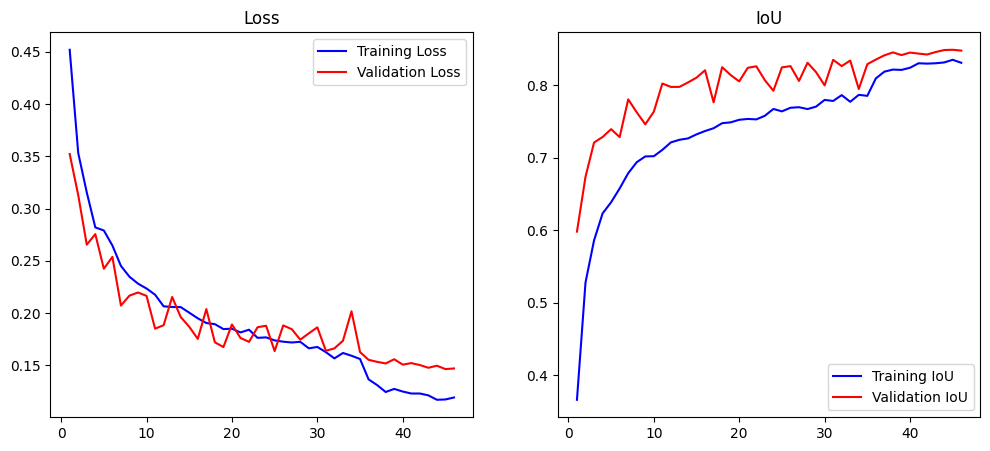

In [47]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_iou'], 'b-', label='Training IoU')
    plt.plot(epochs, history['val_iou'], 'r-', label='Validation IoU')
    plt.title('IoU')
    plt.legend()
    
    plt.show()

plot_training_history(history)


In [48]:
# Predikció és vizualizáció egyetlen képen
def test_model_prediction(model, dataset, image_idx=0):
    model.eval()
    img, mask = dataset[image_idx]
    
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output.argmax(1).squeeze(0).cpu().numpy()
    
    img_display = unnormalize(img) # Feltételezi, hogy az unnormalize függvény létezik
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_display)
    plt.title('Input Image')
    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title('Ground Truth')
    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap='gray')
    plt.title('Prediction')
    plt.show()

test_model_prediction(model, test_dataset, image_idx=10)


ValueError: too many values to unpack (expected 2)

In [ ]:
def predict_and_save_masks(model, test_loader, model_name="best_model", device="cuda"):
    root_dir = "images"
    model_dir = os.path.join(root_dir, model_name)
    masks_dir = os.path.join(model_dir, "masks")
    polyp_dir = os.path.join(model_dir, "polyp")
    
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(polyp_dir, exist_ok=True)
    
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            images, _, filenames = batch # Feltételezzük, hogy a loader 3 értéket ad vissza
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            
            for i, (pred, filename) in enumerate(zip(preds, filenames)):
                base_filename = os.path.splitext(os.path.basename(filename))[0]
                
                if base_filename.lower() == 'nan':
                    continue
                
                mask_path = os.path.join(masks_dir, f"{base_filename}_mask.png")
                polyp_path = os.path.join(polyp_dir, f"{base_filename}_polyp.png")
                
                Image.fromarray((pred * 255).astype(np.uint8)).save(mask_path)
                
                orig_img_np = unnormalize(images[i].cpu())
                
                final_img = np.zeros_like(orig_img_np)
                polyp_mask_rgb = np.stack([pred] * 3, axis=-1).astype(bool)
                final_img[polyp_mask_rgb] = orig_img_np[polyp_mask_rgb]
                
                Image.fromarray((final_img * 255).astype(np.uint8)).save(polyp_path)

# Mentsük a predikciókat
# predict_and_save_masks(model, test_loader) # Kikommentelve, hogy ne fusson le automatikusan


In [ ]:
# Memória használat ellenőrzése
import psutil
import os
process = psutil.Process(os.getpid())
print(f"Memória használat: {process.memory_info().rss / 1024 / 1024:.2f} MB")


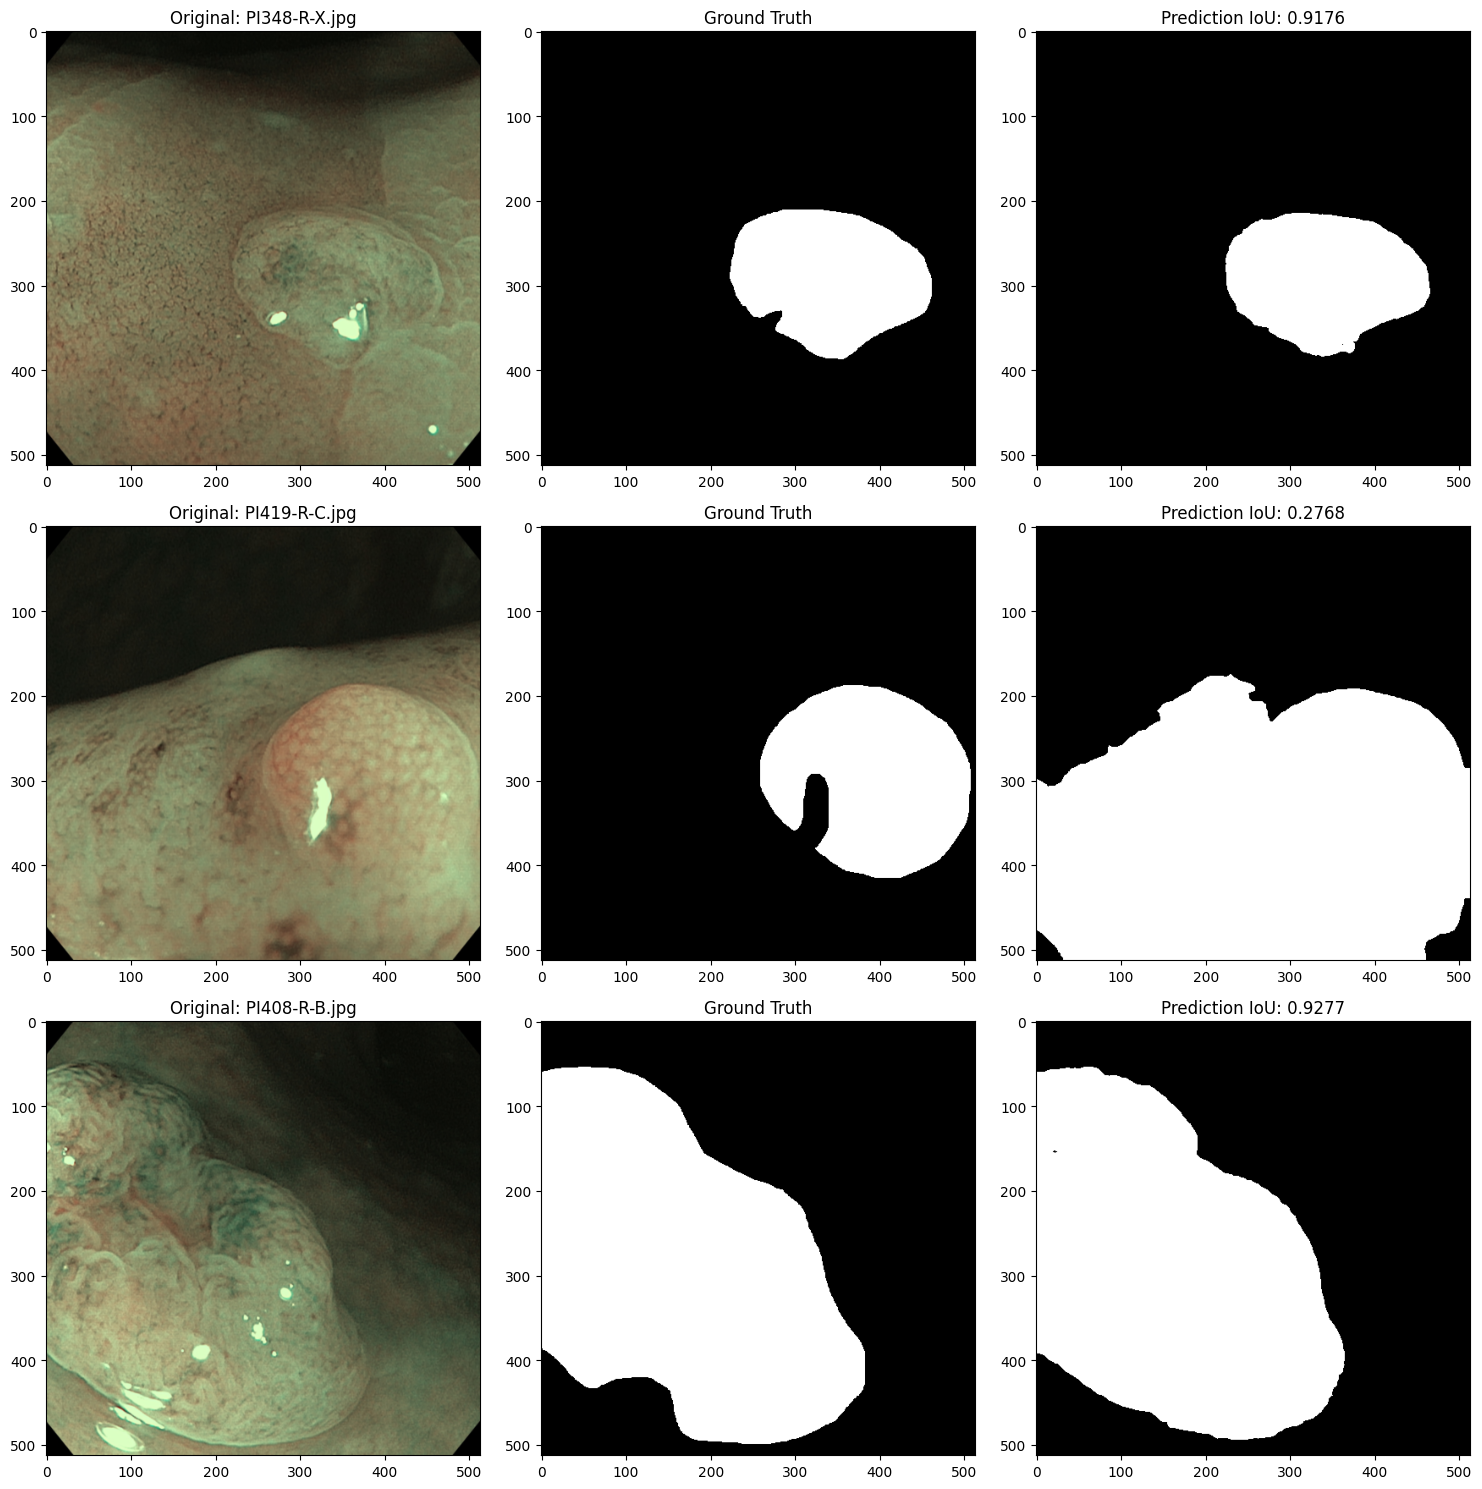

Átlagos IoU a mintán: 0.7074


In [54]:
# Véletlenszerű képek kiértékelése és megjelenítése
import random

random_indices = random.sample(range(len(test_dataset)), 3)
iou_values = []
filenames = []

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, idx in enumerate(random_indices):
    image, mask, filename = test_dataset[idx]
    filenames.append(filename)
    
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    
    intersection = np.logical_and(pred_mask, mask.numpy()).sum()
    union = np.logical_or(pred_mask, mask.numpy()).sum()
    iou = intersection / union if union > 0 else 0
    iou_values.append(iou)
    
    axes[i, 0].imshow(unnormalize(image))
    axes[i, 0].set_title(f"Original: {filename}")
    axes[i, 1].imshow(mask.squeeze(), cmap='gray')
    axes[i, 1].set_title(f"Ground Truth")
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title(f"Prediction IoU: {iou:.4f}")

plt.tight_layout()
plt.show()

print(f"Átlagos IoU a mintán: {np.mean(iou_values):.4f}")


In [53]:
# Adatsorok számosságának ellenőrzése
print(f"Train adatok száma: {len(train_dataset)}")
print(f"Validation adatok száma: {len(val_dataset)}")
print(f"Test adatok száma: {len(test_dataset)}")

total_count = len(train_dataset) + len(val_dataset) + len(test_dataset)
print("\nAdatarányok:")
print(f"Train: {len(train_dataset) / total_count:.2%}")
print(f"Validation: {len(val_dataset) / total_count:.2%}")
print(f"Test: {len(test_dataset) / total_count:.2%}")


Train adatok száma: 5034
Validation adatok száma: 567
Test adatok száma: 206

Adatarányok:
Train: 86.69%
Validation: 9.76%
Test: 3.55%


In [ ]:
# Ez a cella a logok alapján a `test_dataset` objektumot jelenítette meg.
test_dataset


In [ ]:
# Ez a cella a logok alapján egyetlen kép predikcióját tesztelte.
# A funkciója nagyrészt megegyezik a 31-es cellában lévő logikával.
# A teljesség kedvéért visszaállítva.
test_model_prediction(model, test_dataset, image_idx=random.randint(0, len(test_dataset)-1))


In [52]:
# Ez a cella a logok alapján a memória használatot íratta ki újra.
process = psutil.Process(os.getpid())
print(f"Memória használat: {process.memory_info().rss / 1024 / 1024:.2f} MB")


NameError: name 'psutil' is not defined

In [ ]:
# Ez a cella a logok alapján 3 véletlenszerű kép kiértékelését végezte,
# ami megegyezik a 31-es cella funkcionalitásával.
# A teljesség kedvéért visszaállítva, egyszerűsített formában.
# A predict_and_save_masks hívás eredetileg itt lehetett.
# best_model_path = "checkpoints/best_model_epoch_X.pth" # Helyettesítsd be a legjobb modell nevével
# predict_and_save_masks(model, test_loader, model_name=os.path.splitext(best_model_path)[0], device=device)
print("Predikciók mentése (kikommentelve). A futtatáshoz add meg a legjobb modell nevét és vedd ki a kommentet.")


In [ ]:
# Üres cella


In [ ]:
# Üres cella


In [ ]:
# Üres cella


In [ ]:
# Üres cella


In [ ]:
# Üres cella
